Используя базу "Аудиожанры", примените подход к музыке как к тексту и напишите сверточный классификатор (на базе слоя Conv1D) для подготовленных данных. Для этого:

1. Измените подготовку данных так, чтобы набор признаков, извлекаемый из аудиофайла, был представлен в виде последовательностей векторов признаков. Последовательности должны быть фиксированного размера и выбираться скользящим окном c заданным шагом. Другими словами: берем аудио-файл длительность, например, 30 сек. Берем отрезок фиксированной длины (например, 5с) и получаем набор признаков для этого отрезка. Смещаемся на шаг (например, 1с) и берем следующий отрезок. Таким образом готовим обучающую вборку.
2. Длину последовательности, размер шага и достаточный набор признаков определите самостоятельно исходя из требований к точности классификатора;
3. Разработайте классификатор на одномерных сверточных слоях **Conv1D** с точностью классификации жанра на тестовых данных не ниже **60%**, а на обучающих файлах - **68%** и выше;
4. Используйте за основу материал с урока, но при желании разработайте свои инструменты.

Импортируем необходимые библиотеки:

## 1. Импорт библиотек

In [14]:
# Массивы
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Преобразование категориальных данных в one hot encoding
from tensorflow.keras.utils import to_categorical

# Работа с папками и файлами
import os

# Утилиты работы со временем
import time

# Работа со случайными числами
import random

# Математические функции
import math

# Сохранение и загрузка структур данных Python
import pickle

# Параметризация аудио
import librosa

# Оптимизаторы для обучения моделей
from tensorflow.keras.optimizers import Adam, RMSprop

# Конструирование и загрузка моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model, load_model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM, GlobalAveragePooling1D
from tensorflow.keras.layers import MaxPooling1D, AveragePooling1D, SpatialDropout1D

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Загрузим датасет в Colab:

## 2. Загрузка датасета genres

In [2]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip', None, quiet=True)

'genres.zip'

## 3. Распаковка и проверка структуры

In [3]:
# Распаковка архива на локальный диск colab
!unzip -qo genres.zip

# Проверка выгруженных папок
!ls genres

# Проверка содержимого одной папки
!ls genres/blues

blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock
blues.00000.au	blues.00020.au	blues.00040.au	blues.00060.au	blues.00080.au
blues.00001.au	blues.00021.au	blues.00041.au	blues.00061.au	blues.00081.au
blues.00002.au	blues.00022.au	blues.00042.au	blues.00062.au	blues.00082.au
blues.00003.au	blues.00023.au	blues.00043.au	blues.00063.au	blues.00083.au
blues.00004.au	blues.00024.au	blues.00044.au	blues.00064.au	blues.00084.au
blues.00005.au	blues.00025.au	blues.00045.au	blues.00065.au	blues.00085.au
blues.00006.au	blues.00026.au	blues.00046.au	blues.00066.au	blues.00086.au
blues.00007.au	blues.00027.au	blues.00047.au	blues.00067.au	blues.00087.au
blues.00008.au	blues.00028.au	blues.00048.au	blues.00068.au	blues.00088.au
blues.00009.au	blues.00029.au	blues.00049.au	blues.00069.au	blues.00089.au
blues.00010.au	blues.00030.au	blues.00050.au	blues.00070.au	blues.00090.au
blues.00011.au	blues.00031.au	blues.00051.au	blues.00071.au	blues.00091.au
blues.00012.au	blues.00032.a

## 4. Параметры аудио 

In [63]:
SR = 22050
DURATION_SEC = 30
WINDOW_SEC = 5
HOP_SEC = 2
N_FFT = 2048
HOP_LENGTH = 512
N_MFCC = 20

WINDOW_LEN = WINDOW_SEC * SR
HOP_LEN = HOP_SEC * SR
MAX_SEQ_LEN = (DURATION_SEC - WINDOW_SEC) // HOP_SEC + 1

## 5. Функция extract_features

In [64]:
def extract_features(y, sr, start):
    end = start + WINDOW_LEN
    window = y[start:end]
    if len(window) < WINDOW_LEN:
        return None

    mfcc = librosa.feature.mfcc(y=window, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rms = librosa.feature.rms(y=window, hop_length=HOP_LENGTH)
    cent = librosa.feature.spectral_centroid(y=window, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)

    return np.concatenate([np.mean(mfcc, axis=1), [np.mean(rms)], [np.mean(cent)]])

## 6. Функция file_to_sequence (преобразование файла в последовательность векторов)

In [65]:
def file_to_sequence(file_path):
    y, _ = librosa.load(file_path, sr=SR, duration=DURATION_SEC)
    seq = []
    for start in range(0, len(y) - WINDOW_LEN + 1, HOP_LEN):
        feat = extract_features(y, SR, start)
        if feat is not None:
            seq.append(feat)
        if len(seq) >= MAX_SEQ_LEN:
            break
    while len(seq) < MAX_SEQ_LEN:
        seq.append(np.zeros(N_MFCC + 2))
    return np.array(seq)

## 7. Подготовка данных

In [66]:
CLASS_LIST = sorted(os.listdir('./genres'))
CLASS_COUNT = len(CLASS_LIST)

X, Y = [], []
for class_idx, name in enumerate(CLASS_LIST):
    for f in range(90):
        path = f'./genres/{name}/{name}.{str(f).zfill(5)}.au'
        X.append(file_to_sequence(path))
        Y.append(class_idx)
    print(f'{name} готов')

X = np.array(X)
Y = to_categorical(Y, CLASS_COUNT)

print(f'X shape: {X.shape}, Y shape: {Y.shape}')

blues готов
classical готов
country готов
disco готов
hiphop готов
jazz готов
metal готов
pop готов
reggae готов
rock готов
X shape: (900, 13, 22), Y shape: (900, 10)


## 8. Нормирование данных (StandardScaler)

In [67]:
scaler = StandardScaler()
shape = X.shape
X = scaler.fit_transform(X.reshape(-1, shape[-1])).reshape(shape)

## 9. Разделение на обучающую и валидационную выборки

In [68]:
x_train, x_val, y_train, y_val = train_test_split(X, Y, stratify=Y, test_size=0.1)
print(f'x_train: {x_train.shape}, x_val: {x_val.shape}')

x_train: (810, 13, 22), x_val: (90, 13, 22)


## 10. Создание модели Conv1D

In [69]:
model = Sequential([
    Input(shape=(MAX_SEQ_LEN, N_MFCC + 2)),

    Conv1D(128, 5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(256, 5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(512, 3, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(CLASS_COUNT, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 13, 128)        │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 13, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 6, 256)         │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 6, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 3, 512)         │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 3, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 742,154 (2.83 MB)

 Trainable params: 739,850 (2.82 MB)

 Non-trainable params: 2,304 (9.00 KB)

## 11. Обучение модели

Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.2160 - loss: 2.7025 - val_accuracy: 0.3222 - val_loss: 2.0611 - learning_rate: 5.0000e-04
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3506 - loss: 2.0348 - val_accuracy: 0.3778 - val_loss: 1.8601 - learning_rate: 5.0000e-04
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3753 - loss: 2.0079 - val_accuracy: 0.3889 - val_loss: 1.6511 - learning_rate: 5.0000e-04
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4086 - loss: 1.8478 - val_accuracy: 0.4111 - val_loss: 1.5929 - learning_rate: 5.0000e-04
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4198 - loss: 1.8159 - val_accuracy: 0.5444 - val_loss: 1.4101 - learning_rate: 5.0000e-04
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.4333 - loss: 1.7115 - val_accuracy: 0.5556 - val_loss: 1.2915 - learning_rate: 5.0000e-04
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 

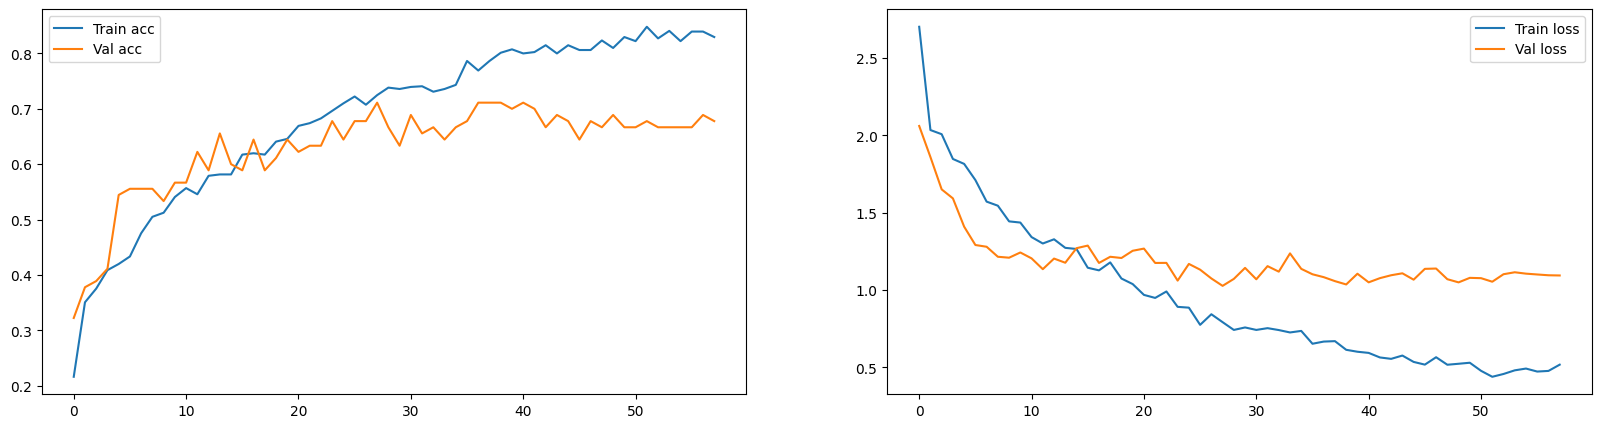

Train accuracy: 0.8296
Val accuracy: 0.6778


In [70]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

history = model.fit(x_train, y_train,
                    validation_data=(x_val, y_val),
                    batch_size=16,
                    epochs=200,
                    callbacks=[early_stop, reduce_lr],
                    verbose=1)

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,5))
ax1.plot(history.history['accuracy'], label='Train acc')
ax1.plot(history.history['val_accuracy'], label='Val acc')
ax1.legend()
ax2.plot(history.history['loss'], label='Train loss')
ax2.plot(history.history['val_loss'], label='Val loss')
ax2.legend()
plt.show()

print(f"Train accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")

## 12. Оценка на тестовых файлах

Test accuracy: 0.6000 (60.0%)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


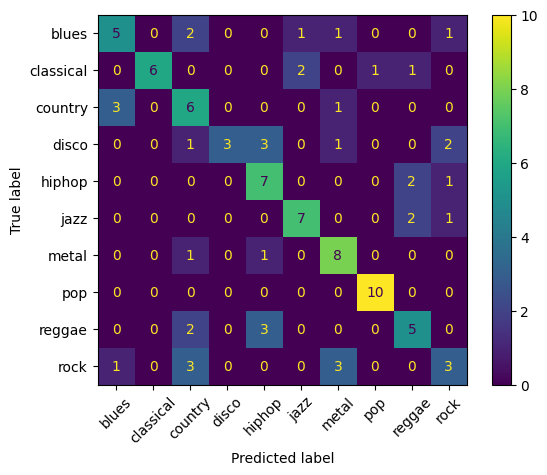

In [71]:
X_test, Y_test = [], []
for class_idx, name in enumerate(CLASS_LIST):
    for f in range(90, 100):
        path = f'./genres/{name}/{name}.{str(f).zfill(5)}.au'
        X_test.append(file_to_sequence(path))
        Y_test.append(class_idx)

X_test = np.array(X_test)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
Y_test = to_categorical(Y_test, CLASS_COUNT)

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f'Test accuracy: {acc:.4f} ({acc*100:.1f}%)')

# Матрица ошибок
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(Y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_LIST)
disp.plot(xticks_rotation=45)
plt.show()